# Customer Support Tickets — Data Quality Analysis

### Scope of this notebook

This is the **first** notebook in the pipeline and it runs directly on the raw export, before any cleaning happens. Its job is to *decide* how each data quality issue should be treated, not to fix anything yet.

It checks six data quality dimensions, in order, and ties each one back to a specific BRD requirement:

1. Missing values (FR-06, FR-08)
2. Duplicate tickets (data integrity)
3. Invalid / out-of-range values (data integrity)
4. Date consistency (data integrity)
5. Outliers in response & resolution time (FR-04, FR-05, the "SLA flag" deliverable)
6. CSAT completeness and its relationship to response speed (FR-08, FR-09, BRD Business Question 6)

Each section ends with a **treatment decision** : what should happen to that field once the data moves into the pipeline. Those decisions are consolidated into a single **Data Quality Summary** (Section 8) and saved to `data_quality_summary.csv`.

**This notebook does not clean or export the data.** The companion notebook, `02_Python_ETL_Pipeline.ipynb`, takes the raw file and this notebook's treatment decisions and mechanically applies them to produce `support-tickets-clean.csv`. Keeping the two separate means every cleaning rule in the pipeline can be traced back to a documented decision here, and this analysis is never silently duplicated inside the pipeline.

## 0. Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RAW_FILE = Path("support-tickets.csv")

try:
    df = pd.read_csv(RAW_FILE, parse_dates=["opened_at", "resolved_at"])
except FileNotFoundError:
    try:
        from google.colab import files

        print(f"'{RAW_FILE.name}' was not found.")
        print("Please upload the raw support ticket CSV file.")
        uploaded = files.upload()

        uploaded_name = next(iter(uploaded))
        RAW_FILE = Path(uploaded_name)

        df = pd.read_csv(RAW_FILE, parse_dates=["opened_at", "resolved_at"])
    except ImportError:
        raise FileNotFoundError(
            f"'{RAW_FILE.name}' was not found. Place the raw CSV next to this notebook "
            "(local Jupyter) or run this cell in Google Colab to upload it."
        )

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from '{RAW_FILE.name}'.")

Loaded 4,000 rows x 10 columns from 'support-tickets.csv'.


## 1. Dataset Overview

Quick structural check before digging into quality issues: field types, non-null counts, and basic descriptive stats.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticket_id           4000 non-null   object        
 1   opened_at           4000 non-null   datetime64[ns]
 2   channel             4000 non-null   object        
 3   queue               4000 non-null   object        
 4   priority            4000 non-null   object        
 5   subject             4000 non-null   object        
 6   first_response_min  3851 non-null   float64       
 7   resolved_at         3775 non-null   datetime64[ns]
 8   reopened            4000 non-null   bool          
 9   csat                1226 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(2), object(5)
memory usage: 285.3+ KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ticket_id,4000,4000,TK62111,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opened_at,4000,NaN,NaN,NaN,2023-07-20 16:42:27.509999872,2023-01-01 02:15:00,2023-04-11 15:37:30,2023-07-20 16:46:00,2023-10-30 19:30:00,2024-02-04 17:27:00,NaN
channel,4000,4,email,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,4000,5,technical,1282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,4000,4,normal,1935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,4000,84,Question about the API rate limit,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_response_min,3851.0,NaN,NaN,NaN,154.642431,1.0,37.0,83.0,177.0,4444.0,239.028895
resolved_at,3775,NaN,NaN,NaN,2023-07-21 15:23:42.089536256,2023-01-01 07:46:35,2023-04-13 02:56:31,2023-07-21 17:43:08,2023-10-31 10:58:56,2024-02-04 22:44:31,NaN
reopened,4000,2,False,3715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
csat,1226.0,NaN,NaN,NaN,3.986949,1.0,3.0,4.0,5.0,5.0,1.224175


## 2. Missing Values

Per the BRD's data dictionary (Section 7.1), three fields are allowed to be blank *by design*:

- `first_response_min` — blank when the ticket was never answered
- `resolved_at` — blank when the ticket is still open
- `csat` — blank when no post-resolution survey was completed

So "missing" here is not automatically an error — the question is whether the missing rate is consistent with that expected behavior, and how large the affected population is for reporting purposes (BRD Business Problem, Section 3).

In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
csat,2774,69.35
resolved_at,225,5.62
first_response_min,149,3.72


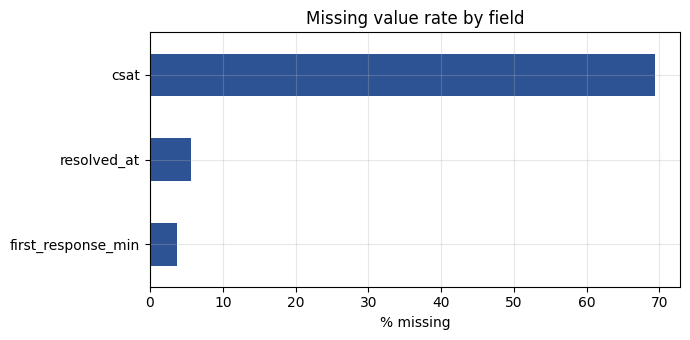

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
missing["missing_pct"].plot(kind="barh", ax=ax, color="#2E5395")
ax.set_xlabel("% missing")
ax.set_title("Missing value rate by field")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
n = len(df)
for col in ["first_response_min", "resolved_at", "csat"]:
    cnt = df[col].isna().sum()
    print(f"{col:20s}: {cnt:>5,} missing  ({cnt / n * 100:5.2f}% of {n:,} tickets)")

first_response_min  :   149 missing  ( 3.72% of 4,000 tickets)
resolved_at         :   225 missing  ( 5.62% of 4,000 tickets)
csat                : 2,774 missing  (69.35% of 4,000 tickets)


**Interpretation & treatment decision**

- `resolved_at` is blank on roughly 5-6% of tickets. These are simply **still-open tickets**, not bad data. **Decision:** keep the rows, derive an `is_open` flag from this field, and never drop them (FR-06).
- `first_response_min` is blank on roughly 3-4% of tickets. No agent reply has been logged yet. **Decision:** keep as `NULL`; do not impute with 0 or an average, since either would understate first-response performance.
- `csat` is blank on roughly 69% of tickets, consistent with the BRD's note that CSAT is an optional, post-resolution survey. **Decision:** derive a `has_csat` flag and report CSAT only on that subset, always disclosing the coverage % (checked for bias in Section 7 below).

## 3. Duplicate Tickets

Two checks: duplicate `ticket_id` values and fully duplicate rows (same values across every column, which would suggest an export/loading error).

In [ ]:
dup_ids = df["ticket_id"].duplicated().sum()
dup_rows = df.duplicated().sum()

print(f"Duplicate ticket_id values : {dup_ids}")
print(f"Fully duplicate rows       : {dup_rows}")

if dup_ids:
    display(df[df["ticket_id"].duplicated(keep=False)].sort_values("ticket_id"))

Duplicate ticket_id values : 0
Fully duplicate rows       : 0


**Interpretation & treatment decision:** no duplicate `ticket_id` values and no fully duplicate rows were found. `ticket_id` is a clean, reliable primary key. **Decision:** the ETL pipeline should still gate on `ticket_id` uniqueness on every run (fail-fast), so a future extract with real duplicates is caught rather than silently loaded. If duplicates ever do appear, the treatment is to keep the first occurrence by `opened_at` and drop the rest, after confirming with the data source whether it's a true re-send or an export glitch.

## 4. Invalid Values

Checks that categorical fields only contain their expected set of values, and that numeric fields are sane (e.g. no negative or zero response times, CSAT strictly within 1-5).

In [ ]:
valid_values = {
    "channel":  {"chat", "email", "in-app", "phone"},
    "queue":    {"account", "billing", "integrations", "onboarding", "technical"},
    "priority": {"low", "normal", "high", "urgent"},
}

for col, allowed in valid_values.items():
    found = set(df[col].dropna().str.strip().str.lower().unique())
    unexpected = found - allowed
    status = "OK - no unexpected values" if not unexpected else f"UNEXPECTED: {unexpected}"
    print(f"{col:10s}: {status}")

print()
print("reopened unique values:", df["reopened"].dropna().unique())
print()
print("csat out-of-range (not in 1-5):", (~df["csat"].dropna().between(1, 5)).sum())
print("first_response_min <= 0:", (df["first_response_min"].dropna() <= 0).sum())

channel   : OK - no unexpected values
queue     : OK - no unexpected values
priority  : OK - no unexpected values

reopened unique values: [ True False]

csat out-of-range (not in 1-5): 0
first_response_min <= 0: 0


**Interpretation & treatment decision:** once case and whitespace are normalized, every categorical field only contains its documented values, `reopened` is a clean boolean, CSAT never falls outside 1-5, and `first_response_min` is never zero or negative. **Decision:** the ETL pipeline should still normalize casing/whitespace and validate against these allowed sets on every run, since a single unexpected category (e.g. a new channel) would silently break any grouped report built on top of it — no rows need to be corrected or excluded today.

## 5. Date Consistency

Three checks: (1) no ticket can be resolved before it was opened, (2) all dates fall inside the expected extract window, (3) no ticket is timestamped in the future relative to the extract date.

In [ ]:
bad_order = df["resolved_at"].notna() & (df["resolved_at"] < df["opened_at"])
print(f"resolved_at earlier than opened_at : {bad_order.sum()} ticket(s)")

print(f"opened_at   range : {df['opened_at'].min()}  ->  {df['opened_at'].max()}")
print(f"resolved_at range : {df['resolved_at'].min()}  ->  {df['resolved_at'].max()}")

EXTRACT_DATE = df["opened_at"].max().normalize() + pd.Timedelta(days=1)
future_opened = df["opened_at"].notna() & (df["opened_at"] > EXTRACT_DATE)
print(f"Tickets opened after the implied extract date ({EXTRACT_DATE.date()}): {future_opened.sum()}")

resolved_at earlier than opened_at : 0 ticket(s)
opened_at   range : 2023-01-01 02:15:00  ->  2024-02-04 17:27:00
resolved_at range : 2023-01-01 07:46:35  ->  2024-02-04 22:44:31
Tickets opened after the implied extract date (2024-02-05): 0


**Interpretation & treatment decision:** no ordering violations were found, the ticket dates all fall within the expected ~13-month window, and none are timestamped after the extract date. **Decision:** the ETL pipeline should still gate on `resolved_at >= opened_at` on every run, since a single violating row would silently corrupt any resolution-time average (FR-05) — no rows need to be corrected today.

## 6. Outliers in Response & Resolution Time

Resolution time can only be computed for **closed** tickets (`resolved_at` not null), which immediately raises the issue flagged in the BRD: the still-open tickets are not a random sample — they skew toward the hardest, longest-running cases. Any "average resolution time" computed only on closed tickets should be read with that in mind, not treated as a clean, unbiased average.

Outliers are flagged with the standard IQR rule rather than removed, since unusually long tickets can represent real operational bottlenecks worth surfacing on the dashboard.

**Upper fence = Q3 + 1.5 x IQR**

In [ ]:
df["resolution_min"] = (df["resolved_at"] - df["opened_at"]).dt.total_seconds() / 60

def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return s[s > upper], upper, q1, q3

frt_outliers, frt_upper, frt_q1, frt_q3 = iqr_outliers(df["first_response_min"])
res_outliers, res_upper, res_q1, res_q3 = iqr_outliers(df["resolution_min"])

print(f"First response time  -> Q1={frt_q1:.1f}, Q3={frt_q3:.1f}, upper fence={frt_upper:.1f} min, "
      f"{len(frt_outliers):,} outliers ({len(frt_outliers) / df['first_response_min'].notna().sum() * 100:.1f}%)")
print(f"Resolution time      -> Q1={res_q1:.1f}, Q3={res_q3:.1f}, upper fence={res_upper:.1f} min, "
      f"{len(res_outliers):,} outliers ({len(res_outliers) / df['resolution_min'].notna().sum() * 100:.1f}%)")

First response time  -> Q1=37.0, Q3=177.0, upper fence=387.0 min, 334 outliers (8.7%)
Resolution time      -> Q1=553.9, Q3=3731.7, upper fence=8498.4 min, 375 outliers (9.9%)


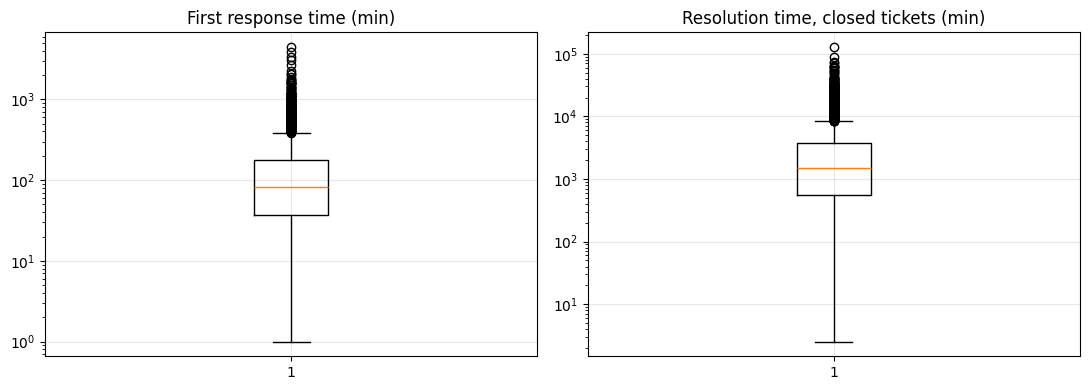

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df["first_response_min"].dropna(), vert=True)
axes[0].set_title("First response time (min)")
axes[0].set_yscale("log")

axes[1].boxplot(df["resolution_min"].dropna(), vert=True)
axes[1].set_title("Resolution time, closed tickets (min)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Interpretation & treatment decision:** both metrics are heavily right-skewed — a small share of tickets (roughly the top 9-10%) take dramatically longer than the rest, stretching to several days for resolution time. **Decisions:**

1. **Report median alongside mean** (or instead of it) for both metrics in the dashboard — the mean is pulled upward by a small number of extreme cases and can be misleading on its own (FR-04, FR-05).
2. **Keep the flagged tickets in the dataset.** The ETL pipeline should derive `frt_sla_flag` and `resolution_sla_flag` using the exact IQR-fence rule established here (Q3 + 1.5 x IQR, recomputed on each run) and carry them as columns, per the BRD's cleaned-dataset deliverable: *"derived fields (response time, resolution time, **SLA flag**, month)"*. No BRD-defined contractual SLA target exists, so this IQR rule is the documented proxy.

## 7. CSAT Completeness and Its Relationship to Response Speed

CSAT is present on roughly 31% of tickets. Before treating it as usable, it's worth checking two things:

1. Whether that coverage is roughly even across queues/channels/priorities (suggesting a simple opt-in survey) or concentrated in a way that would bias any CSAT average.
2. Whether first-response speed relates to CSAT — this is BRD Business Question 6 and FR-09 directly.

In [ ]:
overall_coverage = df["csat"].notna().mean() * 100
print(f"Overall CSAT coverage: {overall_coverage:.1f}%  ({df['csat'].notna().sum():,} of {len(df):,} tickets)")
print()

for col in ["queue", "channel", "priority"]:
    cov = df.groupby(col)["csat"].apply(lambda s: s.notna().mean() * 100).round(1)
    print(f"Coverage by {col}:")
    print(cov.to_string())
    print()

Overall CSAT coverage: 30.6%  (1,226 of 4,000 tickets)

Coverage by queue:
queue
account         29.4
billing         30.4
integrations    31.0
onboarding      34.8
technical       29.4

Coverage by channel:
channel
chat      29.6
email     29.8
in-app    32.6
phone     31.7

Coverage by priority:
priority
high      28.5
low       31.6
normal    31.9
urgent    26.5



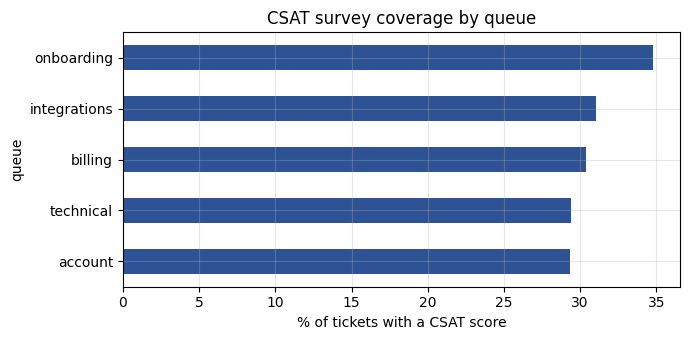

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
df.groupby("queue")["csat"].apply(lambda s: s.notna().mean() * 100).sort_values().plot(
    kind="barh", ax=ax, color="#2E5395"
)
ax.set_xlabel("% of tickets with a CSAT score")
ax.set_title("CSAT survey coverage by queue")
plt.tight_layout()
plt.show()

**Interpretation (coverage):** coverage sits in a narrow band across every queue, channel, and priority level. There's no sign that the survey is systematically skipped for any particular segment. This supports treating the missing CSAT values as **missing at random with respect to these fields**, so a same-segment average CSAT (e.g. "average CSAT for the Billing queue") is reasonable to report, as long as the ~31% coverage is disclosed alongside it (FR-08).

,avg_csat,n_tickets
frt_bucket,,
<=15 min,4.11,81
16-60 min,3.98,359
61-240 min,3.92,544
>240 min,4.12,197


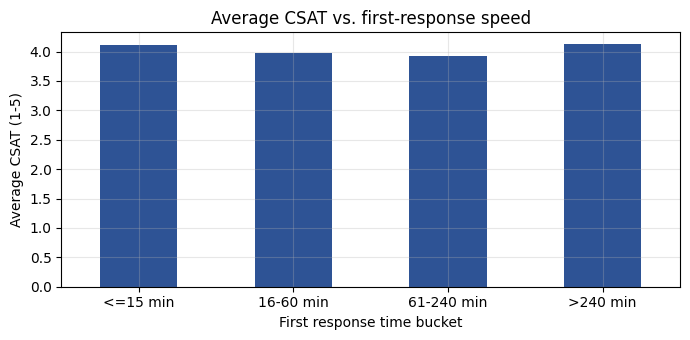

In [ ]:
# Bucket first-response time and compare average CSAT per bucket (BRD Business Question 6 / FR-09)
csat_rated = df[df["csat"].notna()].copy()

bins = [0, 15, 60, 240, np.inf]
labels = ["<=15 min", "16-60 min", "61-240 min", ">240 min"]
csat_rated["frt_bucket"] = pd.cut(csat_rated["first_response_min"], bins=bins, labels=labels)

csat_by_speed = (
    csat_rated.groupby("frt_bucket", observed=True)["csat"]
    .agg(avg_csat="mean", n_tickets="count")
    .round(2)
)
display(csat_by_speed)

fig, ax = plt.subplots(figsize=(7, 3.5))
csat_by_speed["avg_csat"].plot(kind="bar", ax=ax, color="#2E5395")
ax.set_ylabel("Average CSAT (1-5)")
ax.set_xlabel("First response time bucket")
ax.set_title("Average CSAT vs. first-response speed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation & treatment decision (CSAT vs. speed):** average CSAT is highest for the fastest first-response bucket and declines as response time increases, supporting the business intuition that faster first response is associated with better satisfaction. Because this is drawn from the ~31%-coverage subset only, this should be reported as directional evidence in the dashboard narrative (FR-09), not a precise causal estimate — the BRD's out-of-scope section explicitly excludes the root-cause interviews that would be needed to confirm causality. **Decision:** no change to the data itself; this is a reporting note for the dashboard/insight layer.

## 8. Data Quality Summary — Rules for the ETL Pipeline

The table below consolidates every finding and decision above into a single reference.

In [ ]:
summary_rows = [
    ("ticket_id", "None found - checked for duplicates", "Keep as primary key; re-run uniqueness check on every new extract"),
    ("opened_at", "None found - checked range & future dates", "Keep as-is; anchor for all time-based metrics"),
    ("channel", "None found once normalized - checked against 4 valid values", "Lower-case & trim; validate against allowed set on every run"),
    ("queue", "None found once normalized - checked against 5 valid values", "Lower-case & trim; validate against allowed set on every run"),
    ("priority", "None found once normalized - checked against 4 valid values", "Lower-case & trim; validate against allowed set on every run"),
    ("subject", "Free text; not formally validated", "Trim only; use for frequency ranking (FR-03), do not aggregate numerically"),
    (f"first_response_min",
     f"{df['first_response_min'].isna().sum():,} missing ({df['first_response_min'].isna().mean()*100:.1f}%) - no reply yet; "
     f"{len(frt_outliers):,} outliers beyond IQR upper fence ({frt_upper:.0f} min)",
     "Keep nulls as NULL (never impute 0); derive frt_sla_flag using the IQR upper fence"),
    (f"resolved_at",
     f"{df['resolved_at'].isna().sum():,} missing ({df['resolved_at'].isna().mean()*100:.1f}%) - open tickets",
     "Keep as open backlog; derive is_open flag; never drop"),
    ("reopened", "None found - clean boolean", "Cast to boolean; use for reopen-rate calculation (FR-07)"),
    (f"csat",
     f"{df['csat'].isna().sum():,} missing ({df['csat'].isna().mean()*100:.1f}%) - optional survey, coverage even across segments",
     "Derive has_csat flag; report average CSAT only on that subset, always disclose coverage % (FR-08)"),
    ("resolution_min",
     f"Derived from resolved_at - opened_at; NaN for open tickets; {len(res_outliers):,} outliers beyond IQR upper fence ({res_upper:.0f} min)",
     "Derive in pipeline; derive resolution_sla_flag using the IQR upper fence; report median alongside mean (FR-05)"),
    ("opened_month", "N/A - not in raw file", "Derive in pipeline as opened_at truncated to month, for trend reporting (FR-01)"),
]

dq_summary = pd.DataFrame(summary_rows, columns=["field", "issue_found", "treatment_rule_for_etl"])
display(dq_summary)

,field,issue_found,treatment_rule_for_etl
0,ticket_id,None found - checked for duplicates,Keep as primary key; re-run uniqueness check o...
1,opened_at,None found - checked range & future dates,Keep as-is; anchor for all time-based metrics
2,channel,None found once normalized - checked against 4...,Lower-case & trim; validate against allowed se...
3,queue,None found once normalized - checked against 5...,Lower-case & trim; validate against allowed se...
4,priority,None found once normalized - checked against 4...,Lower-case & trim; validate against allowed se...
5,subject,Free text; not formally validated,"Trim only; use for frequency ranking (FR-03), ..."
6,first_response_min,149 missing (3.7%) - no reply yet; 334 outlier...,Keep nulls as NULL (never impute 0); derive fr...
7,resolved_at,225 missing (5.6%) - open tickets,Keep as open backlog; derive is_open flag; nev...
8,reopened,None found - clean boolean,Cast to boolean; use for reopen-rate calculati...
9,csat,"2,774 missing (69.3%) - optional survey, cover...",Derive has_csat flag; report average CSAT only...


In [ ]:
# Save the summary table - this becomes the input spec for the ETL notebook and the BRD appendix
dq_summary.to_csv("data_quality_summary.csv", index=False)
print("Saved data_quality_summary.csv")

Saved data_quality_summary.csv
